In [1]:
# Install these once if you don't have them (needs internet/CRAN access):
# install.packages(c("ggplot2", "corrplot", "gridExtra"))

library(ggplot2)
library(corrplot)
library(gridExtra)

df <- read.csv("train.csv", stringsAsFactors = FALSE)

cat("Dimensions:", dim(df), "\n")
summary(df$SalePrice)

corrplot 0.95 loaded



Dimensions: 1460 81 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  34900  129975  163000  180921  214000  755000 

Skew raw: 1.879009 
Skew log: 0.1210859 


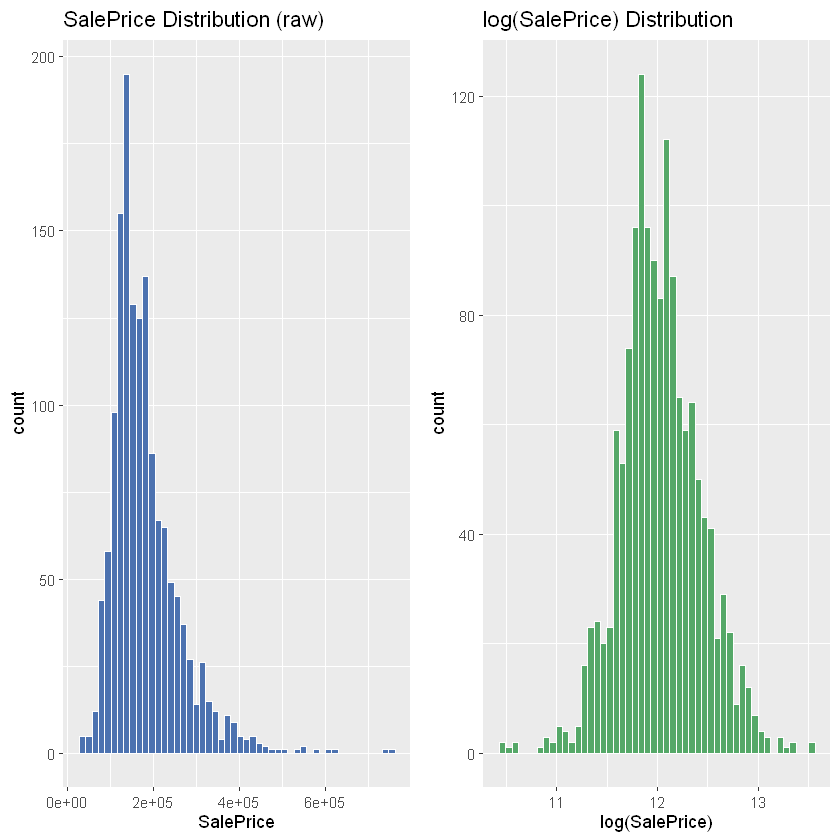

In [2]:
p1 <- ggplot(df, aes(x = SalePrice)) +
  geom_histogram(bins = 50, fill = "#4C72B0", color = "white") +
  labs(title = "SalePrice Distribution (raw)")

p2 <- ggplot(df, aes(x = log(SalePrice))) +
  geom_histogram(bins = 50, fill = "#55A868", color = "white") +
  labs(title = "log(SalePrice) Distribution")

grid.arrange(p1, p2, ncol = 2)

# Skewness helper (base R has no built-in skewness function)
skewness <- function(x) {
  m3 <- mean((x - mean(x))^3)
  s  <- sd(x)
  m3 / s^3
}
cat("Skew raw:", skewness(df$SalePrice), "\n")
cat("Skew log:", skewness(log(df$SalePrice)), "\n")

   SalePrice  OverallQual    GrLivArea   GarageCars   GarageArea  TotalBsmtSF 
       1.000        0.791        0.709        0.640        0.623        0.614 
   X1stFlrSF     FullBath TotRmsAbvGrd    YearBuilt YearRemodAdd  GarageYrBlt 
       0.606        0.561        0.534        0.523        0.507        0.486 
  MasVnrArea   Fireplaces   BsmtFinSF1 
       0.477        0.467        0.386 


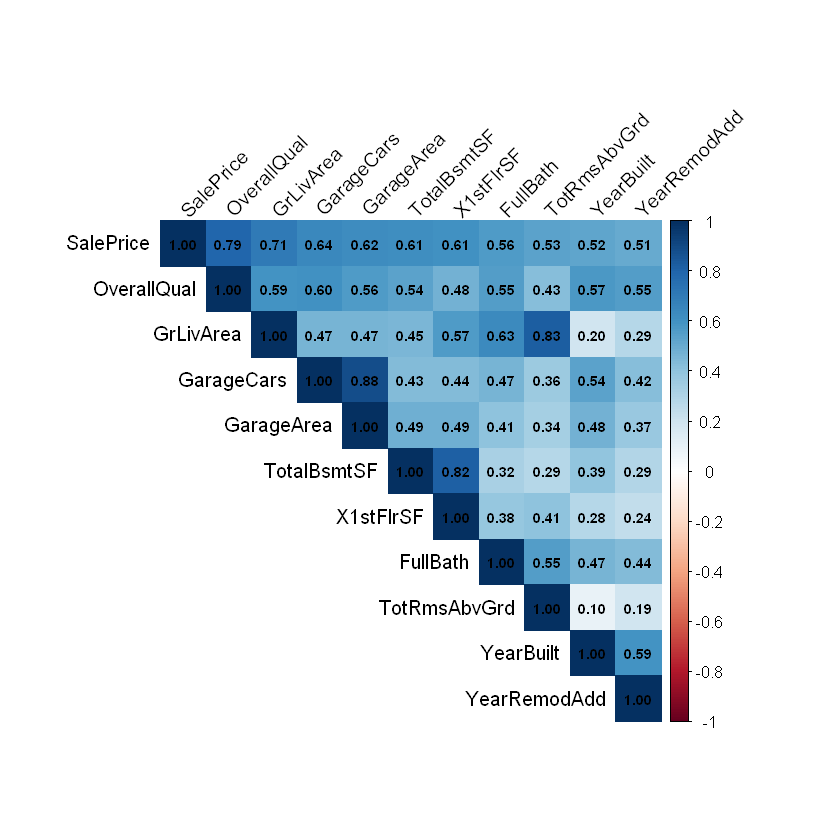

In [3]:
numeric_cols <- sapply(df, is.numeric)
num_df <- df[, numeric_cols]
num_df$Id <- NULL

cors <- cor(num_df, use = "pairwise.complete.obs")
sale_cors <- sort(cors[, "SalePrice"], decreasing = TRUE)
print(round(head(sale_cors, 15), 3))

top_vars <- names(head(sale_cors, 11))
corrplot(cors[top_vars, top_vars], method = "color", type = "upper",
         addCoef.col = "black", number.cex = 0.7, tl.col = "black", tl.srt = 45)

`geom_smooth()` using formula = 'y ~ x'


       Id GrLivArea SalePrice OverallQual
524   524      4676    184750          10
692   692      4316    755000          10
1183 1183      4476    745000          10
1299 1299      5642    160000          10


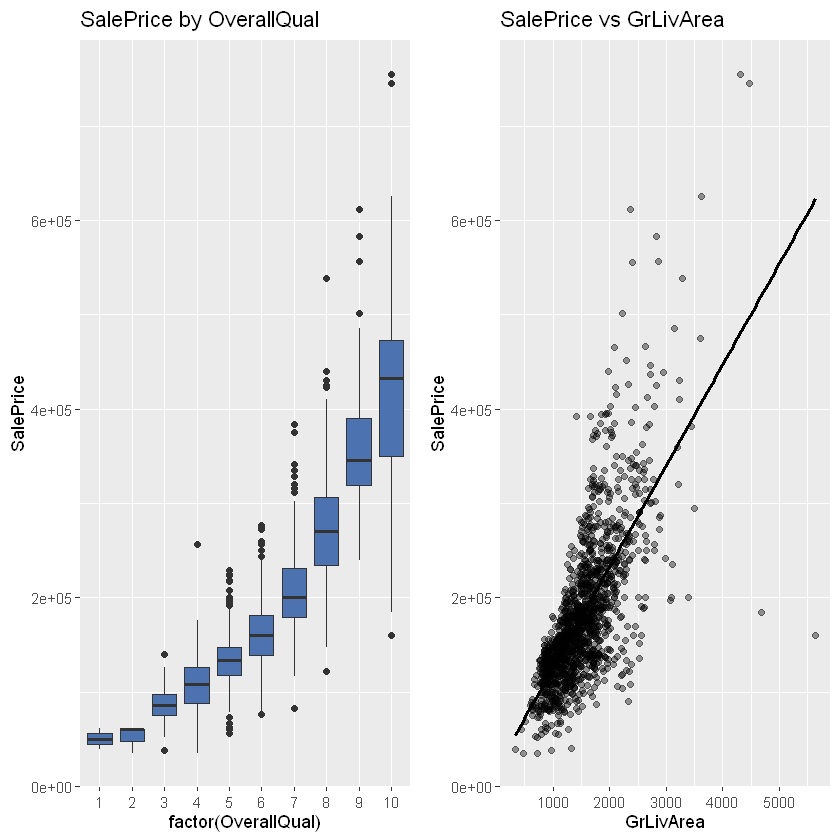

In [4]:
p1 <- ggplot(df, aes(x = factor(OverallQual), y = SalePrice)) +
  geom_boxplot(fill = "#4C72B0") + labs(title = "SalePrice by OverallQual")

p2 <- ggplot(df, aes(x = GrLivArea, y = SalePrice)) +
  geom_point(alpha = 0.4) + geom_smooth(method = "lm", se = FALSE, color = "black") +
  labs(title = "SalePrice vs GrLivArea")

grid.arrange(p1, p2, ncol = 2)

# Flag the outliers
outliers <- df[df$GrLivArea > 4000, c("Id","GrLivArea","SalePrice","OverallQual")]
print(outliers)

[1]   2 225


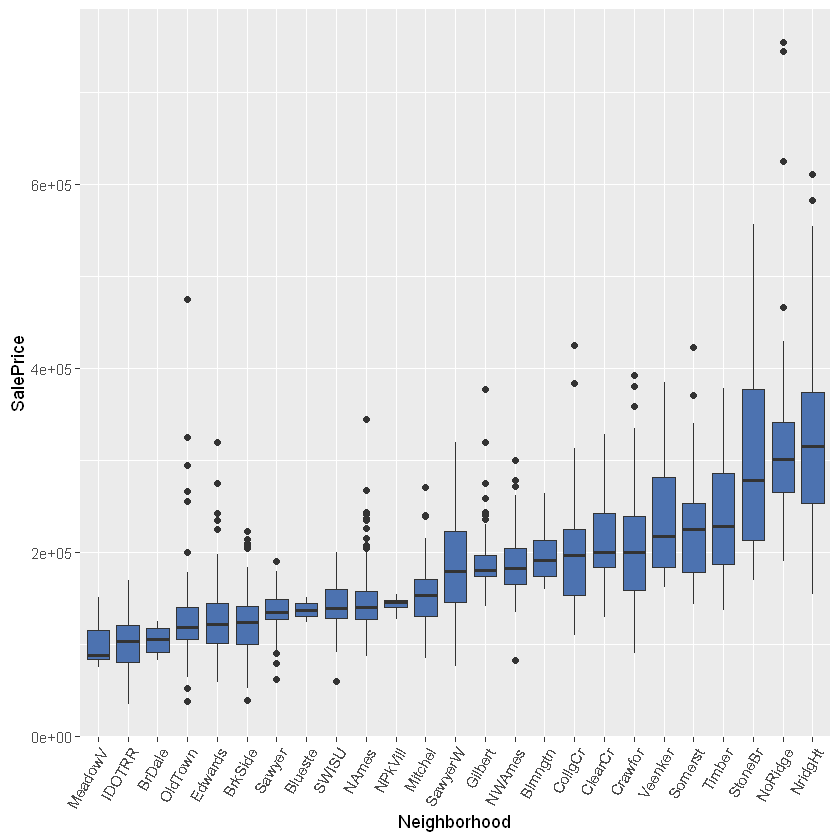

In [5]:
ord <- names(sort(tapply(df$SalePrice, df$Neighborhood, median)))
df$Neighborhood <- factor(df$Neighborhood, levels = ord)

ggplot(df, aes(x = Neighborhood, y = SalePrice)) +
  geom_boxplot(fill = "#4C72B0") +
  theme(axis.text.x = element_text(angle = 60, hjust = 1))

print(range(table(df$Neighborhood)))

In [6]:
df <- read.csv("train.csv", stringsAsFactors = FALSE)

## ---- 1. Re-apply missing value treatment (from Step 7) ----
none_cols <- c("PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
               "GarageType", "GarageFinish", "GarageQual", "GarageCond",
               "BsmtQual", "BsmtCond", "BsmtFinType1", "MasVnrType")
for (col in none_cols) df[[col]][is.na(df[[col]])] <- "None"

mode_val <- function(x) names(sort(table(x), decreasing = TRUE))[1]
df$BsmtExposure[df$Id == 949] <- mode_val(df$BsmtExposure[df$BsmtQual != "None"])
df$BsmtFinType2[df$Id == 333] <- mode_val(df$BsmtFinType2[df$BsmtQual != "None"])
df$BsmtExposure[is.na(df$BsmtExposure)] <- "None"
df$BsmtFinType2[is.na(df$BsmtFinType2)] <- "None"

df$MasVnrArea[is.na(df$MasVnrArea)] <- 0
df$GarageYrBlt[is.na(df$GarageYrBlt)] <- df$YearBuilt[is.na(df$GarageYrBlt)]
df$LotFrontage <- ave(df$LotFrontage, df$Neighborhood,
                       FUN = function(x) ifelse(is.na(x), median(x, na.rm = TRUE), x))
df$Electrical[is.na(df$Electrical)] <- mode_val(df$Electrical[!is.na(df$Electrical)])

## ---- 2. Remove the two confirmed outliers (from Step 4) ----
df <- df[!(df$Id %in% c(524, 1299)), ]

## ---- 3. Ordinal encoding: map text quality scales to ordered integers ----
qual_map    <- c(None = 0, Po = 1, Fa = 2, TA = 3, Gd = 4, Ex = 5)
bsmtexp_map <- c(None = 0, No = 1, Mn = 2, Av = 3, Gd = 4)
bsmtfin_map <- c(None = 0, Unf = 1, LwQ = 2, Rec = 3, BLQ = 4, ALQ = 5, GLQ = 6)
garagefin_map <- c(None = 0, Unf = 1, RFn = 2, Fin = 3)
functional_map <- c(Sal = 0, Sev = 1, Maj2 = 2, Maj1 = 3, Mod = 4, Min2 = 5, Min1 = 6, Typ = 7)
lotshape_map <- c(IR3 = 0, IR2 = 1, IR1 = 2, Reg = 3)
landslope_map <- c(Sev = 0, Mod = 1, Gtl = 2)
paveddrive_map <- c(N = 0, P = 1, Y = 2)
fence_map <- c(None = 0, MnWw = 1, GdWo = 2, MnPrv = 3, GdPrv = 4)

qual_cols <- c("ExterQual","ExterCond","BsmtQual","BsmtCond","HeatingQC",
               "KitchenQual","FireplaceQu","GarageQual","GarageCond","PoolQC")
for (col in qual_cols) df[[col]] <- unname(qual_map[df[[col]]])

df$BsmtExposure  <- unname(bsmtexp_map[df$BsmtExposure])
df$BsmtFinType1  <- unname(bsmtfin_map[df$BsmtFinType1])
df$BsmtFinType2  <- unname(bsmtfin_map[df$BsmtFinType2])
df$GarageFinish  <- unname(garagefin_map[df$GarageFinish])
df$Functional    <- unname(functional_map[df$Functional])
df$LotShape      <- unname(lotshape_map[df$LotShape])
df$LandSlope     <- unname(landslope_map[df$LandSlope])
df$PavedDrive    <- unname(paveddrive_map[df$PavedDrive])
df$Fence         <- unname(fence_map[df$Fence])
df$CentralAir    <- ifelse(df$CentralAir == "Y", 1, 0)

## ---- 4. Combined / derived features ----
df$TotalSF     <- df$TotalBsmtSF + df$X1stFlrSF + df$X2ndFlrSF
df$HouseAge    <- df$YrSold - df$YearBuilt
df$RemodAge    <- df$YrSold - df$YearRemodAdd
df$GarageAge   <- df$YrSold - df$GarageYrBlt
df$TotalBath   <- df$FullBath + 0.5 * df$HalfBath + df$BsmtFullBath + 0.5 * df$BsmtHalfBath
df$TotalPorchSF <- df$OpenPorchSF + df$EnclosedPorch + df$X3SsnPorch + df$ScreenPorch

df$HasPool      <- ifelse(df$PoolArea > 0, 1, 0)
df$HasGarage    <- ifelse(df$GarageArea > 0, 1, 0)
df$Has2ndFloor  <- ifelse(df$X2ndFlrSF > 0, 1, 0)
df$HasBsmt      <- ifelse(df$TotalBsmtSF > 0, 1, 0)
df$HasFireplace <- ifelse(df$Fireplaces > 0, 1, 0)

## ---- 5. Sanity checks ----
cat("Rows after outlier removal:", nrow(df), "\n")
cat("HouseAge < 0:", sum(df$HouseAge < 0), "\n")
cat("RemodAge < 0:", sum(df$RemodAge < 0), "\n")
cat("GarageAge < 0:", sum(df$GarageAge < 0), "\n")

print(head(df[, c("Id","TotalSF","HouseAge","RemodAge","TotalBath","TotalPorchSF")]))
print(names(df)[sapply(df, is.character)])  # nominal cols still needing encoding

saveRDS(df, "train_engineered.rds")
cat("Saved train_engineered.rds -", nrow(df), "rows x", ncol(df), "cols\n")

Rows after outlier removal: 1458 
HouseAge < 0: 0 
RemodAge < 0: 0 
GarageAge < 0: 0 
  Id TotalSF HouseAge RemodAge TotalBath TotalPorchSF
1  1    2566        5        5       3.5           61
2  2    2524       31       31       2.5            0
3  3    2706        7        6       3.5           42
4  4    2473       91       36       2.0          307
5  5    3343        8        8       3.5           84
6  6    2158       16       14       2.5          350
 [1] "MSZoning"      "Street"        "Alley"         "LandContour"  
 [5] "Utilities"     "LotConfig"     "Neighborhood"  "Condition1"   
 [9] "Condition2"    "BldgType"      "HouseStyle"    "RoofStyle"    
[13] "RoofMatl"      "Exterior1st"   "Exterior2nd"   "MasVnrType"   
[17] "Foundation"    "Heating"       "Electrical"    "GarageType"   
[21] "MiscFeature"   "SaleType"      "SaleCondition"
Saved train_engineered.rds - 1458 rows x 92 cols


In [7]:
df <- read.csv("train.csv", stringsAsFactors = FALSE)

# --- Group 1: "None" means the house genuinely doesn't have this feature ---
none_cols <- c("PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
               "GarageType", "GarageFinish", "GarageQual", "GarageCond",
               "BsmtQual", "BsmtCond", "BsmtFinType1",
               "MasVnrType")

for (col in none_cols) {
  df[[col]][is.na(df[[col]])] <- "None"
}

# --- Group 2: The two "true missing" basement fields (house HAS a basement) ---
# Impute using the mode among houses that DO have a basement
mode_val <- function(x) names(sort(table(x), decreasing = TRUE))[1]

df$BsmtExposure[df$Id == 949] <- mode_val(df$BsmtExposure[df$BsmtQual != "None"])
df$BsmtFinType2[df$Id == 333] <- mode_val(df$BsmtFinType2[df$BsmtQual != "None"])
# remaining BsmtExposure/BsmtFinType2 NAs are real "no basement" cases
df$BsmtExposure[is.na(df$BsmtExposure)] <- "None"
df$BsmtFinType2[is.na(df$BsmtFinType2)] <- "None"

# --- Group 3: Numeric structural — MasVnrArea = 0 when no veneer ---
df$MasVnrArea[is.na(df$MasVnrArea)] <- 0

# --- Group 4: GarageYrBlt — no garage, so use YearBuilt as a reasonable stand-in ---
df$GarageYrBlt[is.na(df$GarageYrBlt)] <- df$YearBuilt[is.na(df$GarageYrBlt)]

# --- Group 5: LotFrontage — genuinely missing, impute by Neighborhood median ---
df$LotFrontage <- ave(df$LotFrontage, df$Neighborhood,
                       FUN = function(x) ifelse(is.na(x), median(x, na.rm = TRUE), x))

# --- Group 6: Electrical — only 1 missing, impute with the overall mode ---
df$Electrical[is.na(df$Electrical)] <- mode_val(df$Electrical[!is.na(df$Electrical)])

# --- Verify ---
remaining_na <- sort(colSums(is.na(df)), decreasing = TRUE)
remaining_na <- remaining_na[remaining_na > 0]
print(remaining_na)
cat("\nColumns still with NA:", length(remaining_na), "\n")

named numeric(0)

Columns still with NA: 0 


In [8]:
df <- readRDS("train_engineered.rds")  # output from Step 9 (encoding)

# Skewness helper (same one from Steps 2 & earlier)
skewness <- function(x) {
  x <- x[!is.na(x)]
  m3 <- mean((x - mean(x))^3); s <- sd(x)
  m3 / s^3
}

# The continuous numeric predictors identified back in the skew check
cont_cols <- c("MiscVal","PoolArea","LotArea","X3SsnPorch","LowQualFinSF",
               "BsmtFinSF2","ScreenPorch","EnclosedPorch","MasVnrArea",
               "OpenPorchSF","TotalPorchSF","LotFrontage","WoodDeckSF",
               "GrLivArea","BsmtUnfSF","X1stFlrSF","X2ndFlrSF","TotalSF","BsmtFinSF1")

skew_before <- sapply(df[cont_cols], skewness)

# Only transform columns that cross the standard |skew| > 0.75 threshold
to_transform <- names(skew_before)[abs(skew_before) > 0.75]
cat("Transforming", length(to_transform), "columns:\n")
print(to_transform)

# log1p(x) = log(1 + x) -- handles zeros safely (log(0) is undefined, log1p(0) = 0)
for (col in to_transform) {
  df[[col]] <- log1p(df[[col]])
}

skew_after <- sapply(df[to_transform], skewness)
comparison <- data.frame(before = round(skew_before[to_transform], 2),
                          after  = round(skew_after, 2))
print(comparison[order(-comparison$before), ])

# Transform the target the same way (matches the Step 2 finding: log(SalePrice) is symmetric)
df$SalePrice_log <- log(df$SalePrice)

saveRDS(df, "train_final.rds")
cat("Saved -", nrow(df), "rows x", ncol(df), "cols\n")

Transforming 19 columns:
 [1] "MiscVal"       "PoolArea"      "LotArea"       "X3SsnPorch"   
 [5] "LowQualFinSF"  "BsmtFinSF2"    "ScreenPorch"   "EnclosedPorch"
 [9] "MasVnrArea"    "OpenPorchSF"   "TotalPorchSF"  "LotFrontage"  
[13] "WoodDeckSF"    "GrLivArea"     "BsmtUnfSF"     "X1stFlrSF"    
[17] "X2ndFlrSF"     "TotalSF"       "BsmtFinSF1"   
              before after
MiscVal        24.41  5.16
PoolArea       15.92 15.49
LotArea        12.55 -0.18
X3SsnPorch     10.28  7.71
LowQualFinSF    8.99  7.44
BsmtFinSF2      4.24  2.52
ScreenPorch     4.11  3.14
EnclosedPorch   3.08  2.11
MasVnrArea      2.69  0.51
OpenPorchSF     2.34 -0.02
TotalPorchSF    2.01 -0.51
LotFrontage     1.54 -1.00
WoodDeckSF      1.54  0.16
GrLivArea       1.01 -0.07
BsmtUnfSF       0.92 -2.18
X1stFlrSF       0.89  0.01
X2ndFlrSF       0.81  0.29
TotalSF         0.80 -0.47
BsmtFinSF1      0.76 -0.62
Saved - 1458 rows x 93 cols


In [9]:
df <- readRDS("train_final.rds")

set.seed(42)  # reproducibility -- same folds every time we run this
K <- 5

# Assign each row to one of K folds, shuffled randomly
n <- nrow(df)
fold_id <- sample(rep(1:K, length.out = n))

# RMSE helper -- the actual Kaggle scoring metric (on log scale)
rmse <- function(actual, predicted) sqrt(mean((actual - predicted)^2))

# Generic CV runner: takes a function that fits on train data & predicts on test data
run_cv <- function(fit_predict_fn, data, fold_id, K, target_col = "SalePrice_log") {
  fold_scores <- numeric(K)
  for (k in 1:K) {
    train_data <- data[fold_id != k, ]
    valid_data <- data[fold_id == k, ]
    preds <- fit_predict_fn(train_data, valid_data)
    fold_scores[k] <- rmse(valid_data[[target_col]], preds)
  }
  fold_scores
}

# Sanity-check with a simple baseline model
baseline_fit_predict <- function(train_data, valid_data) {
  model <- lm(SalePrice_log ~ OverallQual + GrLivArea, data = train_data)
  predict(model, newdata = valid_data)
}

scores <- run_cv(baseline_fit_predict, df, fold_id, K)

saveRDS(list(fold_id = fold_id, K = K, rmse = rmse, run_cv = run_cv), "cv_setup.rds")

In [10]:
library(glmnet)
library(randomForest)

df <- readRDS("train_final.rds")
cv <- readRDS("cv_setup.rds")
fold_id <- cv$fold_id; K <- cv$K; rmse <- cv$rmse; run_cv <- cv$run_cv

drop_cols <- c("Id", "SalePrice", "SalePrice_log")
feature_cols <- !(names(df) %in% drop_cols)
X <- as.matrix(model.matrix(~ . - 1, data = df[, feature_cols]))
y <- df$SalePrice_log

if (any(!is.finite(X)) || any(!is.finite(y))) {
  stop("The model input contains NA, NaN, or Inf values.")
}

## Ridge (alpha=0) and Lasso (alpha=1)
set.seed(42)
cv_ridge <- cv.glmnet(X, y, alpha = 0, foldid = fold_id)
cv_lasso <- cv.glmnet(X, y, alpha = 1, foldid = fold_id)

ridge_rmse <- sqrt(min(cv_ridge$cvm))
lasso_rmse <- sqrt(min(cv_lasso$cvm))

## Random Forest uses the same one-hot encoded feature matrix as glmnet
rf_fit_predict <- function(train_data, valid_data) {
  train_rows <- match(train_data$Id, df$Id)
  valid_rows <- match(valid_data$Id, df$Id)

  model <- randomForest(
    x = X[train_rows, , drop = FALSE],
    y = train_data$SalePrice_log,
    ntree = 100,
    mtry = max(1, floor(sqrt(ncol(X))))
  )

  predict(model, X[valid_rows, , drop = FALSE])
}
rf_scores <- run_cv(rf_fit_predict, df, fold_id, K)

results <- data.frame(
  Model = c("Baseline (2 features)", "Ridge", "Lasso", "Random Forest"),
  CV_RMSE = c(0.1946, ridge_rmse, lasso_rmse, mean(rf_scores))
)
results <- results[order(results$CV_RMSE), ]
print(results, row.names = FALSE)

saveRDS(list(cv_ridge = cv_ridge, cv_lasso = cv_lasso, rf_scores = rf_scores, results = results),
        "model_comparison.rds")

Loading required package: Matrix

Loaded glmnet 5.0

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: 'randomForest'


The following object is masked from 'package:gridExtra':

    combine


The following object is masked from 'package:ggplot2':

    margin




                 Model   CV_RMSE
                 Lasso 0.1114830
                 Ridge 0.1142408
         Random Forest 0.1346716
 Baseline (2 features) 0.1946000


In [11]:
library(gbm)

df <- readRDS("train_final.rds")
cv <- readRDS("cv_setup.rds")
fold_id <- cv$fold_id; K <- cv$K; rmse <- cv$rmse; run_cv <- cv$run_cv
prior <- readRDS("model_comparison.rds")

drop_cols <- c("Id", "SalePrice", "SalePrice_log")
feature_cols <- setdiff(names(df), drop_cols)
X <- as.matrix(model.matrix(~ . - 1, data = df[, feature_cols]))
y <- df$SalePrice_log

if (any(!is.finite(X)) || any(!is.finite(y))) {
  stop("The GBM input contains NA, NaN, or Inf values.")
}

gbm_fit_predict <- function(train_data, valid_data) {
  train_rows <- match(train_data$Id, df$Id)
  valid_rows <- match(valid_data$Id, df$Id)

  model <- gbm.fit(
    x = X[train_rows, , drop = FALSE],
    y = y[train_rows],
    distribution = "gaussian",
    n.trees = 500,
    interaction.depth = 3,
    shrinkage = 0.05,
    bag.fraction = 0.8,
    verbose = FALSE
  )

  predict(model, X[valid_rows, , drop = FALSE], n.trees = 500)
}

set.seed(42)
gbm_scores <- run_cv(gbm_fit_predict, df, fold_id, K)
cat("GBM fold RMSEs:", round(gbm_scores, 4), "\n")
cat("GBM mean CV RMSE:", round(mean(gbm_scores), 4), " SD:", round(sd(gbm_scores), 4), "\n\n")

results <- rbind(prior$results,
                 data.frame(Model = "Gradient Boosting (gbm)", CV_RMSE = mean(gbm_scores)))
results <- results[order(results$CV_RMSE), ]
print(results, row.names = FALSE)

saveRDS(list(cv_ridge = prior$cv_ridge, cv_lasso = prior$cv_lasso,
             rf_scores = prior$rf_scores, gbm_scores = gbm_scores,
             results = results),
        "model_comparison.rds")

Loaded gbm 2.3.1

This version of gbm is no longer under development. Consider transitioning to gbm3, https://github.com/gbm-developers/gbm3

Warning message in gbm.fit(x = X[train_rows, , drop = FALSE], y = y[train_rows], :
"variable 59: Condition2RRAn has no variation."
Warning message in gbm.fit(x = X[train_rows, , drop = FALSE], y = y[train_rows], :
"variable 87: Exterior1stAsphShn has no variation."
Warning message in gbm.fit(x = X[train_rows, , drop = FALSE], y = y[train_rows], :
"variable 90: Exterior1stCBlock has no variation."
Warning message in gbm.fit(x = X[train_rows, , drop = FALSE], y = y[train_rows], :
"variable 93: Exterior1stImStucc has no variation."
Warning message in gbm.fit(x = X[train_rows, , drop = FALSE], y = y[train_rows], :
"variable 104: Exterior2ndCBlock has no variation."
Warning message in gbm.fit(x = X[train_rows, , drop = FALSE], y = y[train_rows], :
"variable 186: MiscFeatureTenC has no variation."
Warning message in gbm.fit(x = X[train_rows, , drop = F

GBM fold RMSEs: 0.1192 0.1156 0.1243 0.1075 0.1155 
GBM mean CV RMSE: 0.1164  SD: 0.0061 

                   Model   CV_RMSE
                   Lasso 0.1114830
                   Ridge 0.1142408
 Gradient Boosting (gbm) 0.1164135
           Random Forest 0.1346716
   Baseline (2 features) 0.1946000


In [ ]:
library(glmnet)
library(gbm)

df <- readRDS("train_final.rds")
cv <- readRDS("cv_setup.rds")
fold_id <- cv$fold_id; K <- cv$K
rmse <- function(actual, predicted) sqrt(mean((actual - predicted)^2))

drop_cols <- c("Id", "SalePrice", "SalePrice_log")
feature_cols <- setdiff(names(df), drop_cols)

# Use a proper numeric matrix for glmnet: one-hot encode categorical variables
X <- model.matrix(~ . - 1, data = df[, feature_cols])
y <- df$SalePrice_log

# Returns out-of-fold predictions for every row (aligned to df's row order) --
# needed because blending requires actual predictions to average, not just RMSE scores
get_oof_preds <- function(fit_predict_fn, K) {
  n <- nrow(df)
  oof <- numeric(n)
  for (k in 1:K) {
    train_idx <- which(fold_id != k)
    valid_idx <- which(fold_id == k)
    oof[valid_idx] <- fit_predict_fn(train_idx, valid_idx)
  }
  oof
}

## ---- Elastic Net (alpha=0.2), fitting fresh per fold ----
en_fit_predict <- function(train_idx, valid_idx) {
  fit <- glmnet(X[train_idx, , drop = FALSE], y[train_idx], alpha = 0.2)
  cvfit <- cv.glmnet(X[train_idx, , drop = FALSE], y[train_idx], alpha = 0.2)
  predict(fit, newx = X[valid_idx, , drop = FALSE], s = cvfit$lambda.min)[, 1]
}
oof_en <- get_oof_preds(en_fit_predict, K)
cat("Elastic Net OOF RMSE:", round(rmse(y, oof_en), 4), "\n")

## ---- Gradient Boosting, same cleaned data ----
# Use the encoded numeric matrix here too; do not pass raw text columns to gbm.
gbm_fit_predict <- function(train_idx, valid_idx) {
  model <- gbm.fit(
    x = X[train_idx, , drop = FALSE],
    y = y[train_idx],
    distribution = "gaussian",
    n.trees = 500,
    interaction.depth = 3,
    shrinkage = 0.05,
    bag.fraction = 0.8,
    verbose = FALSE
  )
  predict(model, newdata = X[valid_idx, , drop = FALSE], n.trees = 500)
}
oof_gbm <- get_oof_preds(gbm_fit_predict, K)
cat("GBM OOF RMSE:", round(rmse(y, oof_gbm), 4), "\n\n")

## ---- Search blend weight w: w * EN + (1-w) * GBM ----
weights <- seq(0, 1, by = 0.05)
blend_rmse <- sapply(weights, function(w) rmse(y, w * oof_en + (1 - w) * oof_gbm))

blend_results <- data.frame(w_elastic_net = weights, blend_rmse = blend_rmse)
best_row <- blend_results[which.min(blend_results$blend_rmse), ]

cat("Blend weight search (w=1 is pure Elastic Net, w=0 is pure GBM):\n")
print(blend_results[order(blend_results$blend_rmse), ][1:8, ], row.names = FALSE)
cat("\nBest blend: w =", best_row$w_elastic_net, " RMSE =", round(best_row$blend_rmse, 4), "\n")

saveRDS(list(oof_en = oof_en, oof_gbm = oof_gbm, blend_results = blend_results,
             best_weight = best_row$w_elastic_net), "blend_results.rds")

Elastic Net OOF RMSE: 0.1112 


ERROR: Error in gbm.fit(x = x, y = y, offset = offset, distribution = distribution, : variable 2: MSZoning is not of type numeric, ordered, or factor.
